In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [60]:
df=pd.read_csv('data/stud.csv')

In [61]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [62]:
!pip install catboost
!pip install xgboost

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor , AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [64]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [65]:
df['Total_Score'] = df['math_score'] + df['writing_score'] + df['reading_score']

In [66]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247


In [67]:
x=df.drop(['Total_Score'], axis=1)
y=df['Total_Score']

In [68]:
x.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [69]:
y.head(2)

0    218
1    247
Name: Total_Score, dtype: int64

In [70]:
numeric_features = x.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x.select_dtypes(include=[object]).columns.tolist()

oh_transformer = OneHotEncoder()
numeric_transformer = StandardScaler()

processor = ColumnTransformer(
    [
        ('num', numeric_transformer, numeric_features),
        ('cat', oh_transformer, categorical_features)
    ])



In [71]:
X=processor.fit_transform(x)

In [72]:
x.shape

(1000, 8)

In [73]:
x

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape , y_train.shape, y_test.shape

((800, 20), (200, 20), (800,), (200,))

In [75]:
y

0      218
1      247
2      278
3      148
4      229
      ... 
995    282
996    172
997    195
998    223
999    249
Name: Total_Score, Length: 1000, dtype: int64

In [76]:
def evaluate_models(true , predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    
    return mae, mse, rmse, r2

In [77]:
models={
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest Regressor": RandomForestRegressor(),
    "KNeighbors Regressor": KNeighborsRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Support Vector Regressor": SVR(),
    "XGBoost Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=0)
}

model_list=[]
r2_score_list=[]

for i in range(len(list(models.values()))):
    model=models[list(models.keys())[i]]
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    mae, mse, rmse, r2=evaluate_models(y_test, y_pred)
    
    model_list.append(list(models.keys())[i])
    r2_score_list.append(r2)





In [78]:
print("List of Models:", model_list)
print("R2 Scores:", r2_score_list)
print("----------------------------")
print("Model Performance Comparison:")
print("Linear Regression R2 Score:", r2_score_list[0])
print("Ridge Regression R2 Score:", r2_score_list[1])
print("Lasso Regression R2 Score:", r2_score_list[2])
print("Random Forest Regressor R2 Score:", r2_score_list[3])
print("KNeighbors Regressor R2 Score:", r2_score_list[4])
print("Gradient Boosting Regressor R2 Score:", r2_score_list[5])
print("AdaBoost Regressor R2 Score:", r2_score_list[6])
print("Support Vector Regressor R2 Score:", r2_score_list[7])
print("XGBoost Regressor R2 Score:", r2_score_list[8])
print("CatBoost Regressor R2 Score:", r2_score_list[9])

List of Models: ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest Regressor', 'KNeighbors Regressor', 'Gradient Boosting Regressor', 'AdaBoost Regressor', 'Support Vector Regressor', 'XGBoost Regressor', 'CatBoost Regressor']
R2 Scores: [1.0, 0.99999963775105, 0.9993568277626039, 0.9938380290541783, 0.9560281762428645, 0.9957136224438072, 0.9785219502540123, 0.7611270325958372, 0.9954314827919006, 0.993457457402165]
----------------------------
Model Performance Comparison:
Linear Regression R2 Score: 1.0
Ridge Regression R2 Score: 0.99999963775105
Lasso Regression R2 Score: 0.9993568277626039
Random Forest Regressor R2 Score: 0.9938380290541783
KNeighbors Regressor R2 Score: 0.9560281762428645
Gradient Boosting Regressor R2 Score: 0.9957136224438072
AdaBoost Regressor R2 Score: 0.9785219502540123
Support Vector Regressor R2 Score: 0.7611270325958372
XGBoost Regressor R2 Score: 0.9954314827919006
CatBoost Regressor R2 Score: 0.993457457402165


In [79]:
print("Best Model:", model_list[np.argmax(r2_score_list)])
print("Best R2 Score:", max(r2_score_list))

Best Model: Linear Regression
Best R2 Score: 1.0


In [80]:
l=list(zip(model_list, r2_score_list))
l


[('Linear Regression', 1.0),
 ('Ridge Regression', 0.99999963775105),
 ('Lasso Regression', 0.9993568277626039),
 ('Random Forest Regressor', 0.9938380290541783),
 ('KNeighbors Regressor', 0.9560281762428645),
 ('Gradient Boosting Regressor', 0.9957136224438072),
 ('AdaBoost Regressor', 0.9785219502540123),
 ('Support Vector Regressor', 0.7611270325958372),
 ('XGBoost Regressor', 0.9954314827919006),
 ('CatBoost Regressor', 0.993457457402165)]

In [81]:
lin_model=LinearRegression()
lin_model.fit(X_train, y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test, y_pred)
accuracy = score * 100

print("Linear Regression R2 Score:", score)
print("Linear Regression Accuracy:", accuracy, "%")

Linear Regression R2 Score: 1.0
Linear Regression Accuracy: 100.0 %


In [82]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2 :", model.score(X_test, y_test))

Train R2: 0.9999436763476204
Test R2 : 0.993457457402165


In [83]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,261,261.0,5.684342e-14
737,192,192.0,0.000000e+00
740,225,225.0,2.842171e-14
660,224,224.0,2.842171e-14
411,245,245.0,5.684342e-14
...,...,...,...
408,165,165.0,0.000000e+00
332,171,171.0,0.000000e+00
208,231,231.0,2.842171e-14
613,216,216.0,2.842171e-14


Text(0, 0.5, 'Predicted Values')

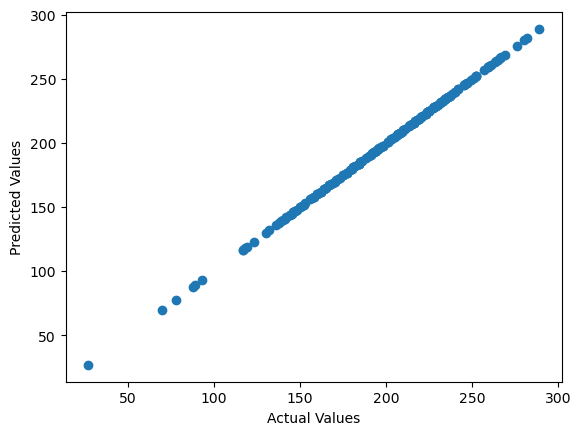

In [84]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")